# ehrapy Imputation Methods Benchmark on PhysioNet2012 Dataset

 Missing data is common in EHR datasets. This tutorial demonstrates ehrapy's imputation methods, their trade-offs, and their performance on the [PhysioNet Challenge 2012](https://physionet.org/content/challenge-2012/1.0.0/) ICU dataset, so you can make an informed choice for your own analysis.

## 1. Imputation Methods within ehrapy

Before we start, let's get an overview of the imputation methods ehrapy offers. The descriptions below summarize the modeling assumption behind each method; Section 5 evaluates their accuracy, distribution preservation, and runtime empirically.

{func}`~ehrapy.preprocessing.explicit_impute` replaces every missing value with a fixed constant (e.g., 0). It requires no model fitting, but replacing all missing entries with a single value introduces a point mass at that constant in the imputed distribution — this matches the ground-truth distribution only if the constant genuinely reflects the missing measurement (e.g., a drug dose that is truly zero when not administered).

{func}`~ehrapy.preprocessing.simple_impute` fills missing values with a column-level statistic (mean, median, or most-frequent value) computed from the observed entries of that variable. It does not use information from other variables, and replacing multiple missing entries with the same statistic reduces the variance of the affected variable relative to the true distribution.

{func}`~ehrapy.preprocessing.locf_impute` (Last Observation Carried Forward) fills each missing timepoint with the most recently observed value for that patient and variable. This assumes the value stays constant between observations; whether that assumption is reasonable depends on how quickly the variable changes physiologically. Timepoints that precede a patient's first observation have nothing to carry forward and are instead filled by a separate `fallback_method`, which defaults to the per-variable mean, so those positions inherit the behavior of `simple_impute` rather than that of LOCF.

{func}`~ehrapy.preprocessing.knn_impute` imputes each gap with the mean of the `n_neighbors` (default 5) most similar rows, where similarity is computed from the variables that both rows observe. It uses cross-row similarity, but requires computing pairwise distances across rows, which increases its computational cost as the dataset grows.

{func}`~ehrapy.preprocessing.miss_forest_impute` follows the MissForest scheme: it iteratively predicts each variable from all others with a tree ensemble, cycling through the variables for a fixed number of passes (`max_iter`, default 3) rather than to a convergence criterion. ehrapy implements this with scikit-learn's `IterativeImputer` and an `ExtraTreesRegressor`, so the per-variable models are extremely randomized trees rather than standard random forests. It can model non-linear relationships between variables, at the cost of fitting one model per variable per iteration. Section 5.3.3 compares runtime and memory usage across all five methods empirically.

All five methods perform *single* imputation: each returns one completed dataset in which the filled-in values are subsequently treated as though they had been observed. None of them carries the uncertainty of the imputation itself into later steps, so standard errors, confidence intervals and p-values computed on an imputed dataset are narrower than they should be. Where that uncertainty matters for the conclusion, the standard remedy is multiple imputation, which repeats the imputation to produce several completed datasets and pools the estimates across them; ehrapy does not currently provide it, so it would have to be run outside the library.

The methods also differ in how they treat the time axis of a 3D layer, which is worth keeping in mind when reading the results below. `locf_impute` operates along that axis by construction. `knn_impute` flattens the layer so that each (patient, timepoint) pair becomes a row, so neighbors are drawn from all patients at all timepoints. `miss_forest_impute` is applied to each timepoint separately, so it uses relationships between variables but no information from other timepoints. `explicit_impute` and `simple_impute` are unaffected by the distinction.

## 2. Environment Setup

So that we can compare these methods, first we need to set up our environment.

/ictstr01/groups/ml01/workspace/eljas.roellin/ehrapy/impute_notebook_ehrapy_v2/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
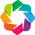

In [1]:
import ehrapy as ep
import ehrdata as ed 
import numpy as np
import pandas as pd

In [ ]:
import warnings

warnings.filterwarnings("ignore")
ep.settings.verbosity = "error"

## 3. Load PhysioNet2012 Dataset

For this analysis, we use the [PhysioNet2012](https://physionet.org/content/challenge-2012/1.0.0/) dataset {cite}`silva2012predicting` {cite}`goldberger2000physiobank`. It records 37 clinical variables at hourly resolution over the first 48 hours of an ICU stay, with per-variable missingness ranging from below 10% to above 99%, so it exercises the imputation methods on densely and sparsely observed time series alike.

In [3]:
edata = ed.dt.physionet2012(layer="tem_data")
edata

EHRData object with n_obs × n_vars × n_t = 11988 × 37 × 48
    obs: 'set', 'Age', 'Gender', 'Height', 'ICUType', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death'
    var: 'Parameter'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47'
    layers: 'tem_data'
    shape of .tem_data: (11988, 37, 48)

## 4. Inspect Missingness on the Full Dataset

Before getting started with looking at the imputation methods and imputing the whole dataset, it is worth understanding the structure of the missing data. `ep.pp.qc_metrics` computes per-variable and per-observation missingness statistics and stores them in `edata.var` and `edata.obs`.

In [4]:
ep.pp.qc_metrics(edata, layer="tem_data")

(          missing_values_abs  missing_values_pct  entropy_of_missingness
 RecordID                                                                
 132539                  1516           85.360360                0.600748
 132540                  1375           77.421171                0.770597
 132541                  1383           77.871622                0.762505
 132543                  1418           79.842342                0.725070
 132545                  1472           82.882883                0.660377
 ...                      ...                 ...                     ...
 163029                  1438           80.968468                0.702131
 163033                  1592           89.639640                0.480316
 163034                  1402           78.941441                0.742601
 163035                  1410           79.391892                0.733925
 163037                  1310           73.761261                0.830328
 
 [11988 rows x 3 columns],
         

### 4.1 Missingness Mechanisms: MCAR, MAR and MNAR

Before choosing how to fill in missing values, it is worth asking why they are missing in the first place. Rubin formalizes three mechanisms {cite}`rubin1976missingdata`:


- MCAR (Missing Completely At Random): the probability that a value is missing does not depend on any observed or unobserved data. Missingness here is pure noise. For example, a device time-out unrelated to the patient's condition.
- MAR (Missing At Random): the probability that a value is missing depends only on observed data (other variables or values already in the dataset), not on the missing value itself. For example, a measurement is missing because a patient's ICU stay was short, and stay length is recorded elsewhere.
- MNAR (Missing Not At Random): the probability that a value is missing depends on the unobserved value itself (or something unmeasured related to it). For example, a lab test is only ordered because a clinician suspects an abnormal result; the fact that it is missing is itself informative about what the result would have been.

This classification matters for two reasons:

1. It determines whether an imputation method's assumptions are valid. `simple_impute`, `knn_impute`, and `miss_forest_impute` all condition only on other observed values, which makes them better justified under MAR — provided the imputation model is reasonably specified — but biased under MNAR, since none of them can account for missingness that depends on the unobserved value itself. `locf_impute` makes a different, time-series-specific assumption (the value stays constant since the last observation), which can hold under MAR but breaks down further under MNAR, since it cannot represent a systematic reason a value stopped being recorded.
2. It tells us whether the masking-based benchmark in Section 5 generalizes to the real missing values. Section 5.1 creates its held-out ground truth by masking already-observed values uniformly at random, a synthetic MCAR mechanism layered on top of the dataset's real missingness. If the real missingness is MAR or MNAR, a method's accuracy on this MCAR-masked benchmark is not guaranteed to reflect its accuracy on the values that are actually missing.

The mechanism cannot be read off the summary statistics above. In particular, `entropy_of_missingness` is the binary entropy of a variable's marginal missing rate, so it is maximal at a rate of 50% and says nothing about whether the missingness is structured: the values near 1.0 for SysABP (45.8% missing), MAP (46.1%), and Weight (47.1%) reflect only how close those rates are to one half. Distinguishing MCAR from MAR or MNAR requires relating the missingness indicator to other variables, not inspecting marginal rates.

Evidence that missingness in ICU EHR data is generally not MCAR therefore comes from elsewhere: laboratory test missingness has been shown to reflect clinician concern about a patient's condition rather than occurring at random {cite}`tan2023informative`, and, in the MIMIC-III ICU database, measurement frequency and missing-data rate together have been shown to be predictive of in-hospital mortality {cite}`shi2025implicit`, suggesting monitoring intensity itself tracks patient severity rather than being independent of it. We therefore treat MAR as a working assumption for this dataset while noting that MNAR cannot be ruled out, and revisit this caveat when interpreting the benchmark (Section 5) and choosing a method (Section 6).

## 5. Set Up the Benchmark

### 5.1 Create a subset of the dataset

First, we want to quantitatively compare methods before applying a specific one to the full dataset. To do that in a manageable computational runtime, we will use a subset of the first 200 observations (a prefix of the dataset, not a random sample). 

In [5]:
edata_bench = edata[:200] #200 patient subset 

We mask 10% of the already-observed values (creating artificial NaNs with a known ground truth) then run each method on an independent copy and compare:

- RMSE and MAE on the held-out positions (accuracy)
- mean and standard deviation differences (distribution preservation)
- runtime and peak memory usage (computational cost)

We use this masking strategy because real-world NaNs in the dataset have no ground truth, so direct accuracy evaluation on them is impossible.

Note that this masking procedure removes already-observed values uniformly at random, which simulates an MCAR mechanism (see Section 4.1) regardless of the dataset's true missingness pattern. The accuracy metrics below therefore measure robustness to MCAR-style perturbations specifically, not necessarily performance on the values that are actually missing.

In [6]:
full_layer = edata_bench.layers["tem_data"].copy() #ground truth

rng = np.random.default_rng(42)
non_nan_mask = ~np.isnan(full_layer)
mask_indices = np.where(non_nan_mask)
n_to_mask = int(0.1 * len(mask_indices[0]))
chosen = rng.choice(len(mask_indices[0]), size=n_to_mask, replace=False)

masked_layer = full_layer.copy()
masked_layer[
    mask_indices[0][chosen], 
    mask_indices[1][chosen], 
    mask_indices[2][chosen]
            ] = np.nan

edata_bench.layers["tem_data"] = masked_layer

# Boolean mask
introduced_mask = np.zeros(full_layer.shape, dtype=bool)
introduced_mask[
    mask_indices[0][chosen], 
    mask_indices[1][chosen], 
    mask_indices[2][chosen]
            ] = True

### 5.2 Run Imputation Methods

Each imputation method gets an independent copy of the masked layer of the subset EHRData, so they don't interfere with each other.

After imputing, we save the evaluation metrics in the results dictionary to be able to see the results clearly.

In [7]:
edata_explicit = edata_bench.copy()
ep.pp.explicit_impute(edata=edata_explicit, layer="tem_data", replacement=0)

In [8]:
edata_simple = edata_bench.copy()
ep.pp.simple_impute(edata=edata_simple, layer="tem_data", strategy="mean")

In [9]:
edata_knn = edata_bench.copy()
ep.pp.knn_impute(edata=edata_knn, layer="tem_data")

In [10]:
edata_miss_forest = edata_bench.copy()
ep.pp.miss_forest_impute(edata=edata_miss_forest, layer="tem_data")

In [11]:
edata_locf = edata_bench.copy()
ep.pp.locf_impute(edata=edata_locf, layer="tem_data")

We also impute here with reduced hyperparameters for the forest-based method (`n_estimators=50, max_iter=1` for `miss_forest_impute`). Section 5.3.4 explains why and reports the resulting cost savings; its accuracy is included alongside the default in the results table below.

In [12]:
edata_miss_forest_reduced = edata_bench.copy()
ep.pp.miss_forest_impute(edata=edata_miss_forest_reduced, layer="tem_data", n_estimators=50, max_iter=1)

### 5.3 Evaluation

We evaluate each imputation method across three dimensions: accuracy against the held-out ground truth, preservation of the variable distributions, and computational cost.

#### 5.3.1 Accuracy Metrics

**RMSE and MAE** tell us how close the imputed values are to the held-out ground truth.


For using these metrics, we need an evaluation method.

In [13]:
def evaluate(imputed_edata):
    from sklearn.metrics import root_mean_squared_error
    from sklearn.metrics import mean_absolute_error

    y_pred = imputed_edata.layers["tem_data"][introduced_mask]
    y_true = full_layer[introduced_mask]
    return {
        "RMSE": float(root_mean_squared_error(y_true=y_true, y_pred=y_pred)),
        "MAE": float(mean_absolute_error(y_true=y_true, y_pred=y_pred)),
        "mean_diff": float(np.abs(np.nanmean(y_pred) - np.nanmean(y_true))),
        "std_diff":  float(np.abs(np.nanstd(y_pred) - np.nanstd(y_true))),
    }

To save the results of our metrics, let's create a dictionary:

In [14]:
results = {}

results["explicit_impute"] = evaluate(edata_explicit)
results["simple_impute"] = evaluate(edata_simple)
results["knn_impute"] = evaluate(edata_knn)
results["miss_forest_impute"] = evaluate(edata_miss_forest)
results["locf_impute"] = evaluate(edata_locf)
results["miss_forest_impute (reduced)"] = evaluate(edata_miss_forest_reduced)

Now we can see how each method's imputation values deviate from the ground truth values:

In [15]:
df_results = pd.DataFrame(results).T
df_results.index.name = "Method"
df_results

,RMSE,MAE,mean_diff,std_diff
Method,,,,
explicit_impute,91.717967,70.792563,70.792012,58.315320
simple_impute,43.244451,18.786436,0.975423,16.462481
knn_impute,42.743747,17.316236,0.480261,16.638894
miss_forest_impute,39.122351,13.759423,1.074179,13.323156
locf_impute,39.664812,12.497735,0.694644,0.362348
miss_forest_impute (reduced),40.217809,14.063725,0.695861,11.096837


#### 5.3.2 Distribution Preservation

An imputation method can have a low RMSE but still shift the mean or collapse the variance. Hence, we have to make sure that the statistical properties of the original data are also maintained at a population level after filling in missing values. For that, we look at the **mean difference and standard deviation difference** which tell us how well the method preserves the global statistics of each variable.

We use raincloud plots to compare the statistical distribution of each variable before and after imputation across all methods.

In [16]:
import matplotlib.pyplot as plt
from bias_utils import distributions_plot

For the distribution plots we want variables with a missingness rate between 20–60%, enough missing data that imputation has something meaningful to do, but not so much that the imputed distribution is dominated by model predictions rather than real observations. We select up to 2 such variables as `PLOT_VARS`; ranked by missingness rate over the full dataset, these are Urine (30.7%) and SysABP (45.8%). For that we are going to look at 3 different timepoints (t=0, t=12, t=24) to see if individual timepoints have become biased or not. Therefore, we first slice each edata object and then plot using `distributions_plot`.

In [17]:
TIMEPOINTS = [0, 12, 24] 

miss_pct = edata.var["missing_values_pct"]
PLOT_VARS = miss_pct[(miss_pct > 20) & (miss_pct < 60)].sort_values().index.tolist()[:2]


In [18]:
%matplotlib inline

Since we need this plot at three timepoints, we factor the logic into plot_distribution_collage(t, edatas, labels, plot_vars): it slices each EHRData object to timepoint `t`, calls the plotting function once per variable, and assembles the resulting panels into a single collage. We then call it once per entry in `TIMEPOINTS`.

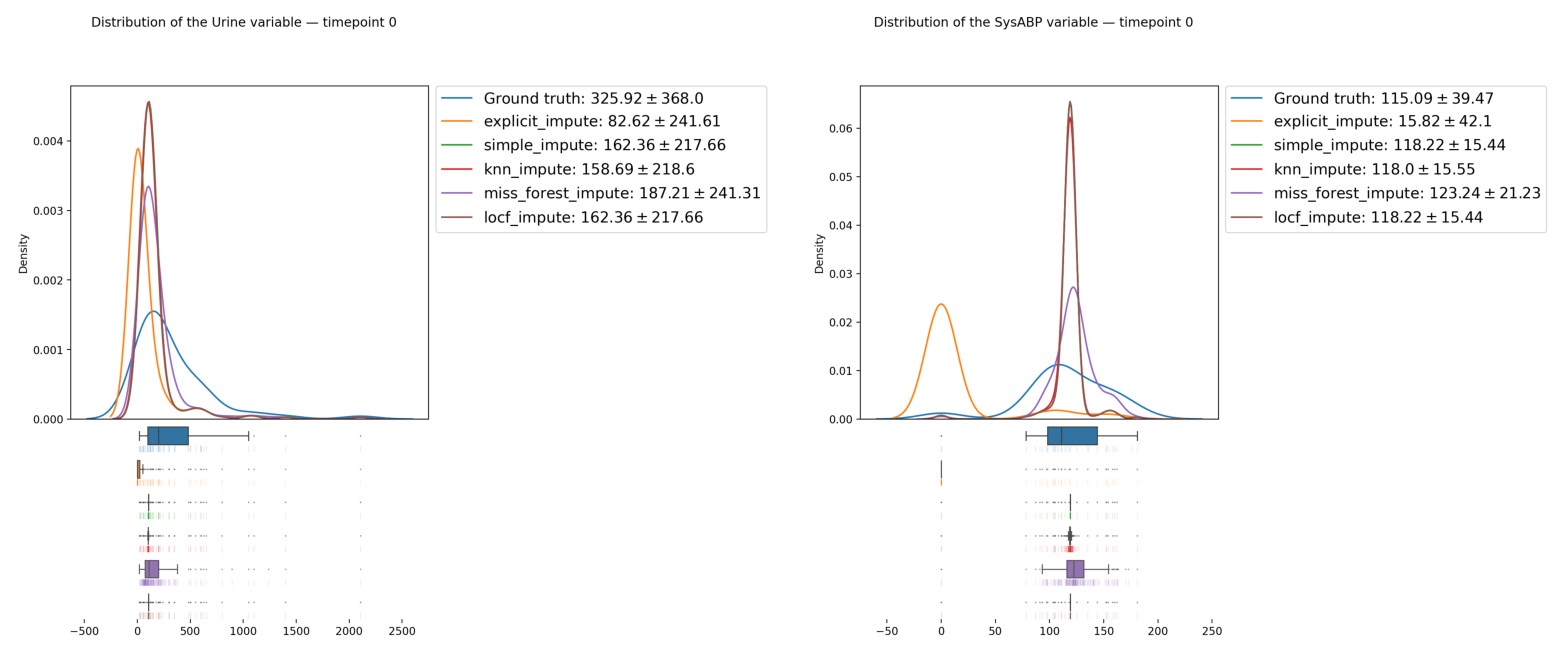

In [19]:
import io


def plot_distribution_collage(t, edatas, labels, plot_vars):
    edatas_at_t = []
    for e in edatas:
        e_t = e[:, :, t].copy()          # 2D slice: obs × var
        X = e_t.layers["tem_data"].copy()
        X = X[:, :, 0]
        e_t.X = X
        edatas_at_t.append(e_t)

    tile_images = []
    for var in plot_vars:
        distributions_plot(labels, edatas_at_t, var)
        fig = plt.gcf()
        ax0 = fig.axes[0]
        handles, legend_labels = ax0.get_legend_handles_labels()
        ax0.legend(handles, legend_labels, fontsize=14, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        plt.suptitle(f"Distribution of the {var} variable — timepoint {t}")

        buf = io.BytesIO()
        fig.savefig(buf, format="png", bbox_inches="tight", dpi=200)
        plt.close(fig)
        buf.seek(0)
        tile_images.append(plt.imread(buf))

    # Size the collage to fill the notebook width, using each tile's actual
    # pixel aspect ratio so images aren't padded with whitespace or distorted.
    n_cols = len(tile_images)
    total_width = 16  # inches
    tile_width = total_width / n_cols
    tile_height = tile_width / (tile_images[0].shape[1] / tile_images[0].shape[0])

    collage_fig, collage_axes = plt.subplots(1, n_cols, squeeze=False, figsize=(total_width, tile_height))
    for ax, img in zip(collage_axes[0], tile_images):
        ax.imshow(img)
        ax.axis("off")
    collage_fig.subplots_adjust(wspace=0)
    collage_fig.tight_layout()
    plt.show()


# `edata_bench` holds the masked layer, so the ground-truth reference has to be
# rebuilt from the unmasked `full_layer` saved in Section 5.1.
edata_truth = edata_bench.copy()
edata_truth.layers["tem_data"] = full_layer.copy()

BENCH_LABELS = ["Ground truth", "explicit_impute", "simple_impute", "knn_impute",
                "miss_forest_impute", "locf_impute"]
BENCH_EDATAS = [edata_truth, edata_explicit, edata_simple, edata_knn,
                 edata_miss_forest, edata_locf]

plot_distribution_collage(TIMEPOINTS[0], BENCH_EDATAS, BENCH_LABELS, PLOT_VARS)

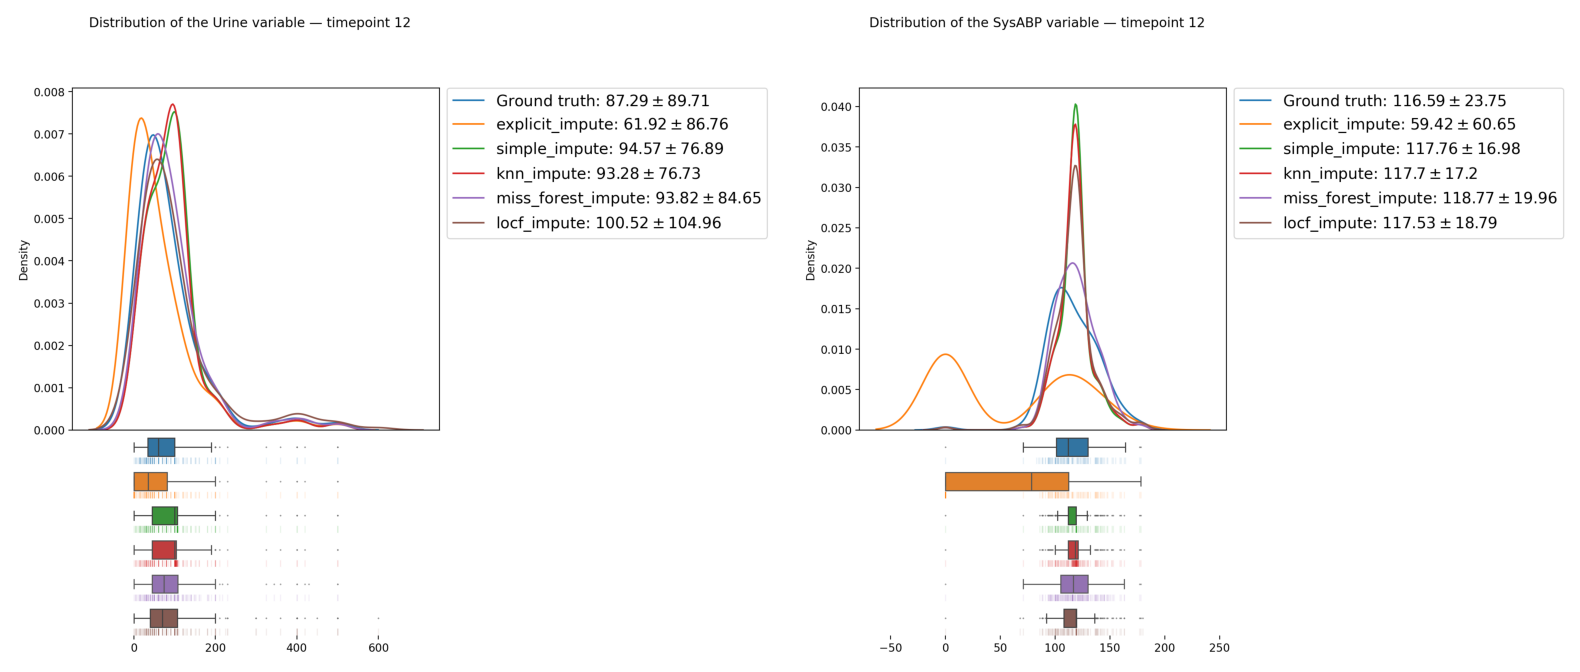

In [20]:
plot_distribution_collage(TIMEPOINTS[1], BENCH_EDATAS, BENCH_LABELS, PLOT_VARS)

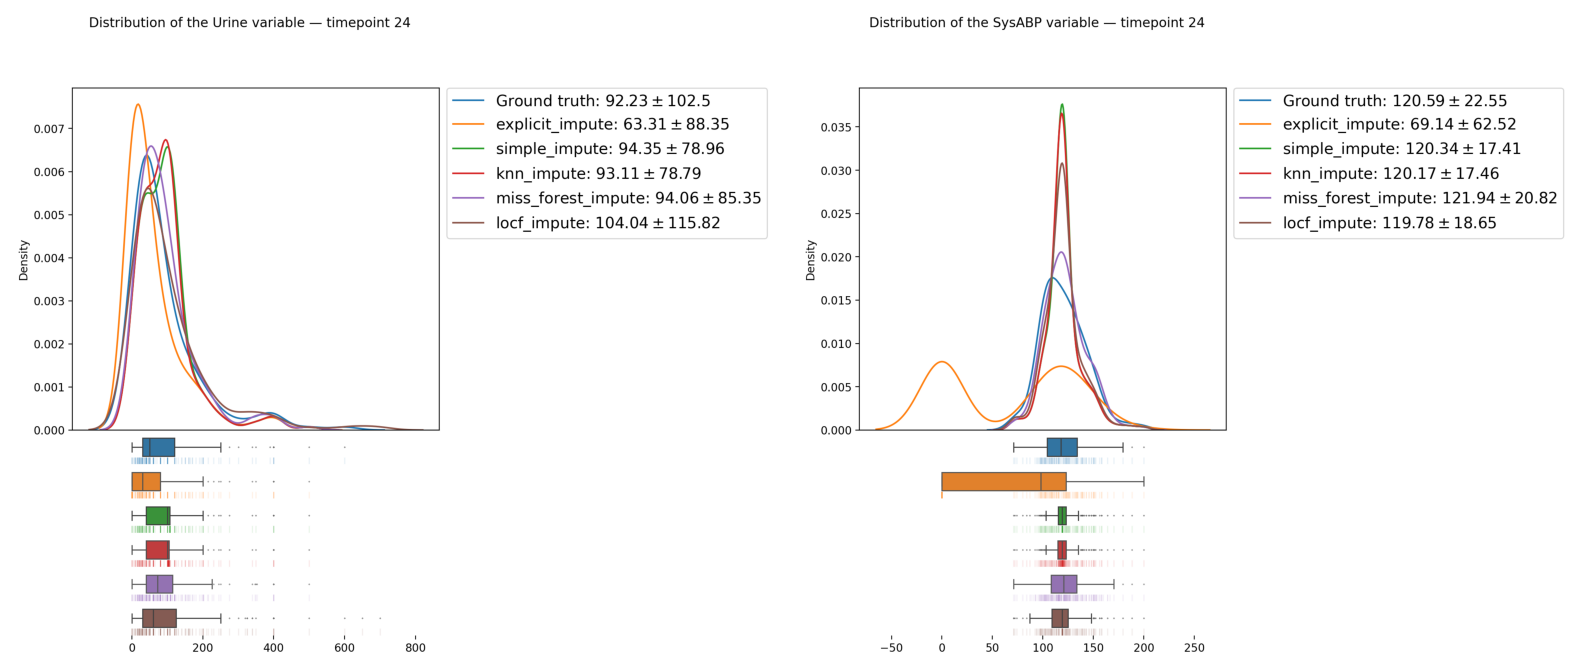

In [21]:
plot_distribution_collage(TIMEPOINTS[2], BENCH_EDATAS, BENCH_LABELS, PLOT_VARS)

#### Key observations (Sections 5.3.1–5.3.2)

The distribution plots (Section 5.3.2) and the aggregate accuracy metrics from Section 5.3.1 together characterize how each method affects the marginal distribution of the imputed variables. These figures come from a single random mask (seed = 42) over the 200-patient subset; we did not repeat the benchmark across multiple seeds or compute confidence intervals, so small differences between methods (e.g., a mean_diff of 0.48 vs. 0.69) should be read as indicative rather than as robust, statistically distinguishable rankings.

`explicit_impute` performs worst by every metric (RMSE = 91.72, MAE = 70.79, mean_diff = 70.79, std_diff = 58.32). Because every missing entry is replaced with the same constant (0), the imputed distribution acquires an artificial mode at that constant that is absent from the ground-truth distribution, shifting both the mean and the variance. This method is appropriate only when the constant carries a genuine clinical meaning.

`locf_impute` has the lowest aggregate std_diff (0.36), the lowest MAE (12.50), and the second-lowest RMSE (39.66) of the five methods. Two caveats apply to this result. First, it is not uniform across timepoints: positions preceding a patient's first observation are filled with the per-variable mean by the default `fallback_method` (Section 1), which compresses variance at early timepoints, while carrying an extreme prior value forward can locally inflate variance later on. The low aggregate std_diff may therefore reflect a partial cancellation of these timepoint-dependent deviations rather than uniform stability; we did not compute per-timepoint metrics to confirm this directly, so it is offered as a plausible explanation consistent with the distribution plots in Section 5.3.2 rather than a demonstrated one. Second, the masking procedure of Section 5.1 removes entries independently, so a masked timepoint almost always has an observed neighbor immediately before it, which is the most favorable possible setting for carrying a value forward. The values that are genuinely missing in this dataset instead occur in long consecutive runs, so LOCF's accuracy here is likely optimistic relative to its behavior on them.

`simple_impute` has a mean_diff (0.98) comparable to `locf_impute` (0.69), but a substantially higher std_diff (16.46 vs. 0.36). Replacing every missing entry with the same column-level statistic removes between-patient variability at the imputed positions, which compresses variance independent of timepoint.

`knn_impute` has the lowest mean_diff of the five methods (0.48) but a std_diff (16.64) similar to `simple_impute`. Averaging over the k nearest neighbors' values produces a smoother, lower-variance estimate than the individual true values at each position.

`miss_forest_impute` has the lowest RMSE (39.12) and the second-lowest MAE (13.76) of the five methods. Its std_diff (13.32) is lower than `simple_impute` and `knn_impute` but higher than `locf_impute`, which is consistent with its use of cross-variable relationships within each timepoint during imputation.

#### 5.3.3 Runtime and Memory Usage

Beyond accuracy, it is also important to consider the computational cost of each method. A method that performs well on 200 patients may become infeasible on the full dataset. We profile computational cost using [Scalene](https://github.com/plasma-umass/scalene), a Python profiler that reports both CPU time and memory usage at line-level granularity.

**Setup**: the five ehrapy imputation methods (`explicit_impute`, `simple_impute` (mean), `locf_impute`, `knn_impute` (k=5), `miss_forest_impute`) were run on nested subsets of the PhysioNet2012 dataset (prefix slices, not independent resamples), with 10% of observed values masked (fixed seed) and 3 repeats per (method, n) combination, each profiled in its own isolated `scalene` subprocess. Runtime is wall-clock seconds for the imputation call; memory is the peak RSS delta in MB.

For both plots, y-axis is log-scale; the summary table shows 3 of the 10 sampled sizes (1000, 5000, 10000) for readability; the plot shows the full grid.

**Runtime**

![](images/runtime_vs_samplesize_impute.png)

![](images/benchmark_runtime_table.png)

- `explicit_impute`, `simple_impute`, and `locf_impute` stay under 4 seconds across the entire range tested (n = 1000–10000), though not perfectly flat: `locf_impute` grows from 0.8 s to 4.0 s (5x) and `simple_impute` from 0.6 s to 2.3 s (~4x) as n grows 10x.
- `knn_impute` grows faster than linearly: 10x the data (n = 1000 → 10000) costs about 50x the runtime (7.5 s → 374 s), consistent with a pairwise-distance-based computation. 
- `miss_forest_impute` scales linearly and predictably: about 350 s per additional 1000 rows across the whole grid (405 s at n = 1000 to 3551 s at n = 10000). It is the most expensive method by far.

**Memory**

![](images/memory_vs_samplesize_impute.png)

![](images/benchmark_memory_table.png)

- `explicit_impute`, `simple_impute`, and `locf_impute` again form the cheapest tier, growing from tens of MB to roughly 200–1400 MB by n = 10000; small relative to the forest-based methods, though (as with runtime) not flat.
- `knn_impute` grows from 268 MB to 1861 MB, a similar order of magnitude to `locf_impute`.
- `miss_forest_impute` is the clear outlier: from 10708 MB at n = 1000 to 106213 MB (~104 GB) at n = 10000, a roughly linear ~10.6 GB per additional 1000 rows.

#### 5.3.4 Hyperparameter Effects on Cost and Accuracy

This section shows that reducing `miss_forest_impute`'s hyperparameters cuts its runtime and memory substantially. Section 5.3.1's results table already includes the method run with these same reduced settings on the same masked 200-patient subset (row `miss_forest_impute (reduced)`); we discuss those numbers below alongside the cost comparison.

![](images/miss_param_comparison_memory.png)

![](images/miss_param_comparison_runtime.png)

Reducing hyperparameters narrows the absolute cost of the forest-based method, but the more important question is what it costs in accuracy — and here the trade is a favorable one. For `miss_forest_impute`, the reduced settings give up a little pointwise accuracy: RMSE rises from 39.12 (default) to 40.22 (reduced) and MAE from 13.76 to 14.06. In exchange, std_diff — the metric most relevant to the variance-preservation argument in Section 6 — improves from 13.32 to 11.10, remaining well ahead of `simple_impute`/`knn_impute`'s ~16.5. Set against the size of the cost saving, that is a small price on this subset, which makes the reduced settings a reasonable default when the method's cost at full size is prohibitive.

As with the rest of Section 5.3.1, this is a single-mask, single-subset comparison, so these differences should be read as indicative rather than robust.

## 6. Choose a Method

The choice of imputation method depends on what matters for your analysis and what computational resources are available.

**If downstream analysis is sensitive to variance (e.g., PCA, clustering, survival modeling)**: among the model-based methods, `miss_forest_impute` preserves the spread of the data best (std_diff 13.32), avoiding the stronger variance compression that `simple_impute` (16.46) and `knn_impute` (16.64) introduce (Section 5.3.1). `locf_impute` preserves variance better still on this benchmark (0.36), but under a considerably stronger assumption and subject to the caveats given in the key observations of Section 5.3. The main drawback of `miss_forest_impute` is computational: it is the most expensive of the five methods tested in both time and memory by a wide margin (its ~10.6 GB per additional 1000 rows memory growth is the main practical constraint on how large a dataset it can handle). Reducing its hyperparameters (`n_estimators=50, max_iter=1`) cuts that cost substantially, trading a little pointwise accuracy (RMSE 39.12 → 40.22) for a further gain in std_diff (13.32 → 11.10, Section 5.3.4), so the reduced setting is the practical choice when the default is out of reach.

**If you need a fast, interpretable baseline:** `simple_impute` and `locf_impute` are the most transparent options for exploratory analysis or when downstream tasks are not sensitive to variance compression, and their cost is negligible at every size we tested (under a few seconds even at n = 10000). `explicit_impute` is equally cheap, but only appropriate when the fill constant is itself clinically meaningful (Section 1); in this benchmark, it had the worst accuracy of all five methods (Section 5.3.1).

**If working with variables that change slowly and are measured frequently:** `locf_impute` is suitable, and like `simple_impute` it is cheap regardless of dataset size. Be cautious with it at early timepoints and on very sparse data, though: positions before a patient's first observation have nothing to carry forward and fall back to the per-variable mean (Section 1), so on sparsely observed variables a substantial share of the result is effectively `simple_impute`.

**If similarity within clusters is a strong signal in the cohort:** `knn_impute` may be advantageous, for example when patients cluster into distinct clinical phenotypes, since borrowing values from the most similar observations could be more informative than a population-level mean (this benchmark did not evaluate clustering behavior directly, so this is an extrapolation from the method's design, not an empirical result). Cost-wise, `knn_impute` is reasonable up to a few thousand rows, but its faster-than-linear runtime growth (Section 5.3.3) makes it increasingly expensive beyond that.

One caveat applies across all of the above: the benchmark in Section 5 evaluates accuracy under an artificial MCAR perturbation (Section 4.1), while the missingness in this dataset is more plausibly MAR or MNAR. Methods that condition on other observed variables (`knn_impute`, `miss_forest_impute`) remain better justified under MAR than methods that use only a variable's own marginal distribution (`simple_impute`) or a single prior value (`locf_impute`), but none of the benchmarked methods explicitly models MNAR missingness, so all rankings above should be read as relative, not absolute. Independently of that, all five are single-imputation methods (Section 1): whichever you choose, the uncertainty introduced by imputation is not reflected in any downstream estimate computed from the result.

## 7. Apply Imputation to the Full Dataset

Based on the benchmarking results, we apply `miss_forest_impute` to the full dataset. It had the lowest RMSE (39.12) and the second-lowest MAE (13.76) of the five methods, and among the model-based methods it preserved the spread of the imputed variables best (std_diff 13.32, Section 5.3.1), which matters for downstream analyses such as clustering or survival analysis that are sensitive to variance.

The trade-off is cost: it is the most expensive method tested in both runtime and memory (Section 5.3.3), so on a dataset of this size the reduced settings of Section 5.3.4 (`n_estimators=50, max_iter=1`) are the more practical starting point and are what we use here. At those settings its RMSE (40.22) is no longer the lowest of the five — `locf_impute` reaches 39.66 — so the run we actually perform trades a little pointwise accuracy for a further gain in variance preservation (std_diff 11.10).

`locf_impute` scores better on both MAE (12.50) and std_diff (0.36), but we do not pick it here: the benchmark masks values independently, so a masked timepoint almost always has an observed neighbor immediately before it, whereas the values genuinely missing in this dataset occur in long consecutive runs (Section 5.3). Its accuracy on this benchmark is therefore optimistic relative to the missingness it would actually face, while `miss_forest_impute`'s numbers carry no equivalent caveat.

We also copy our original data so that we can do our sanity checks later on.

In [22]:
edata_original = edata.copy()
ep.pp.miss_forest_impute(edata, layer="tem_data", n_estimators=50, max_iter=1)

## 8. After Imputation

After imputing, it is important to do two quick sanity checks:
- Value distributions should not shift dramatically
- Temporal trajectory for individual patients should look clinically plausible

To check whether value distributions shifted dramatically, we'll again use the distribution plots from `bias_utils`. This time we compare the original data against the fully imputed data, at the same timepoints t=0, t=12 and t=24 but for three variables that were not shown in Section 5.3.2, so that the check is not limited to the variables already inspected there.

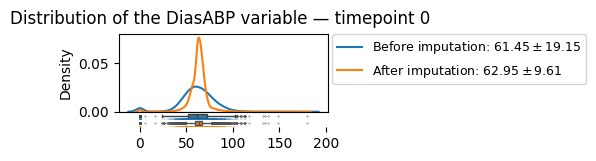

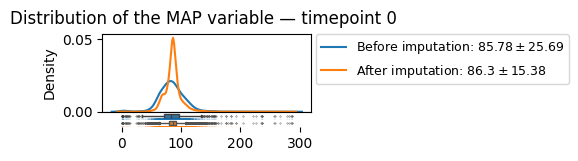

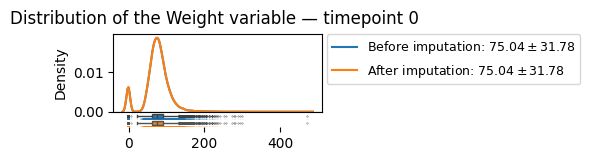

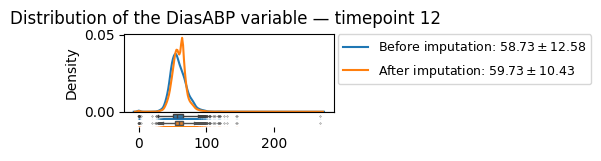

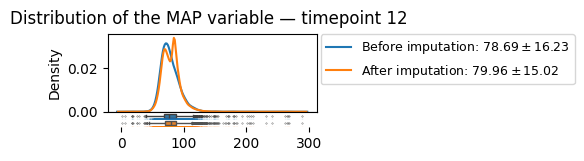

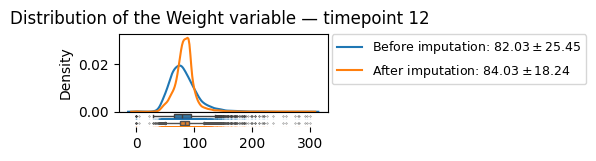

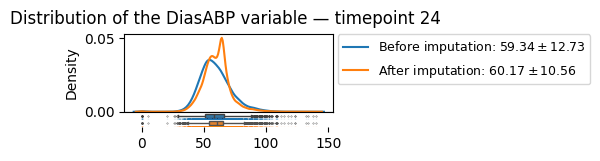

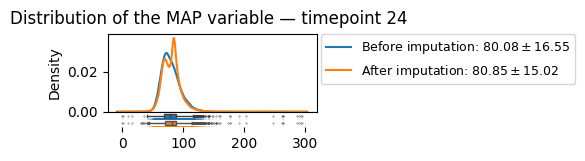

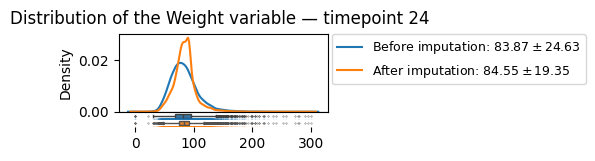

In [23]:
PLOT_VARS = miss_pct[(miss_pct > 20) & (miss_pct < 60)].sort_values().index.tolist()[2:5]

for t in TIMEPOINTS:
    edatas_at_t = []

    for e in [edata_original, edata]:
        e_t = e[:, :, t].copy()          # 2D slice: obs × var
        X = e_t.layers["tem_data"].copy()
        X = X[:, :, 0]
        e_t.X = X
        edatas_at_t.append(e_t)

    for var in PLOT_VARS:
        distributions_plot(
            ["Before imputation", "After imputation"],
            edatas_at_t,
            var,
        )
        fig = plt.gcf()
        ax0 = fig.axes[0]
        handles, labels = ax0.get_legend_handles_labels()
        ax0.legend(handles, labels, fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        fig.set_size_inches(fig.get_size_inches() * 0.45)
        fig.subplots_adjust(top=0.8)
        plt.suptitle(f"Distribution of the {var} variable — timepoint {t}")
    plt.show() 